# Amazon Chronos-2: Zero to Mastery

**A complete, hands-on tutorial on Amazon's Chronos-2 time-series foundation model** — theory,
architecture, benchmarks, and a full, real, end-to-end forecasting project on production-grade
electricity price data.

By the end of this notebook you will be able to:

1. Explain what Chronos-2 is, how its encoder-only T5-derived architecture with a novel
   group-attention mechanism works, and how it differs from Chronos v1 and Chronos-Bolt.
2. Load a pretrained Chronos-2 checkpoint and produce zero-shot point and probabilistic
   (quantile) forecasts on data the model has never seen.
3. Improve forecasts with **native** future covariates — no bolt-on regression required.
4. Use Chronos-2's **cross-learning** mode to share information across a batch of related series.
5. Understand Chronos-2's native **multivariate** forecasting input format.
6. Fine-tune Chronos-2 with LoRA adapters on your own data.
7. Benchmark all of the above against classical baselines, honestly and reproducibly.
8. Know Chronos-2's licensing, production integrations, and real limitations.

## Table of contents

1. [What is Chronos-2?](#what-is-chronos2)
2. [Architecture deep dive](#architecture)
3. [Version history: Chronos v1 vs Chronos-Bolt vs Chronos-2](#versions)
4. [Pretraining corpus & methodology](#pretraining)
5. [Benchmarks](#benchmarks)
6. [Licensing & production integrations](#licensing)
7. [Known limitations](#limitations)
8. [Environment setup](#setup)
9. [The dataset: real electricity prices](#dataset)
10. [Zero-shot forecasting](#zero-shot)
11. [Covariates: native, no bolt-on regression](#covariates)
12. [Cross-learning across related series](#cross-learning)
13. [Native multivariate forecasting (API mechanics)](#multivariate)
14. [Fine-tuning with LoRA](#finetuning)
15. [Final comparison](#final)
16. [References](#references)

> **A note on rigor.** Every factual claim about Chronos-2 in this notebook is cited to a
> primary source — the arXiv technical report, the official GitHub repository, the Hugging Face
> model card, or the official quickstart notebook — and was verified against live sources while
> writing this notebook (July 2026), not recalled from memory. Where a claim we were given
> turned out to be imprecise (for example, "ranked first on GIFT-Eval for open-source models"),
> we say so explicitly and give the more precise, source-grounded version instead of quietly
> repeating the imprecise one.

<a id="what-is-chronos2"></a>
## 1. What is Chronos-2?

**Chronos-2** is Amazon's third-generation time-series foundation model: point it at a new
series it has never seen and it produces a forecast **zero-shot** — no training on your data
required. It builds on two predecessors from the same `chronos-forecasting` package:

- **Chronos (v1)** — treats forecasting as *language modeling*: a series is scaled and quantized
  into discrete tokens from a 4096-token vocabulary, and a standard encoder-decoder T5 language
  model is trained on those tokens with cross-entropy loss. Forecasts come from sampling multiple
  future token trajectories.
- **Chronos-Bolt** — a patch-based variant: chunks history into patches fed to the encoder, and
  the decoder directly generates quantile forecasts for multiple future steps at once ("direct
  multi-step forecasting"), making it up to 250x faster and 20x more memory-efficient than
  original Chronos at the same size.
- **Chronos-2** (Oct 2025) — a new **120M-parameter, encoder-only** model (no decoder at all)
  that closely follows the T5 encoder design, but adds a **group-attention mechanism** that lets
  it natively handle **univariate, multivariate, and covariate-informed** forecasting in a single
  zero-shot pass — the headline capability this notebook is built around.

**Verified facts:**

- **Paper:** *Chronos-2: From Univariate to Universal Forecasting*, arXiv Oct 2025 —
  [arXiv:2510.15821](https://arxiv.org/abs/2510.15821).
- **License:** Apache-2.0 (confirmed directly from the repository's `LICENSE` file).
- **Package:** [`chronos-forecasting`](https://pypi.org/project/chronos-forecasting/) on PyPI;
  source at [github.com/amazon-science/chronos-forecasting](https://github.com/amazon-science/chronos-forecasting).
- **Checkpoints:** [Hugging Face Chronos models collection](https://huggingface.co/collections/amazon/chronos-models-65f1791d630a8d57cb718444),
  primary Chronos-2 checkpoint at [`amazon/chronos-2`](https://huggingface.co/amazon/chronos-2).

**A correction, made honestly up front:** we were asked to build this tutorial around the claim
that Chronos-2 is "ranked first on the GIFT-Eval benchmark for open-source models." We went
looking for that exact sentence in Amazon's own sources and **could not find it verbatim
anywhere** — the arXiv paper, HF model card, and Amazon Science blog all say Chronos-2 achieves
**state-of-the-art results among public/pretrained models** on GIFT-Eval, fev-bench, and Chronos
Benchmark II, and that it **surpasses the previously-leading TiRex and TimesFM-2.5**. That is a
materially similar but not identical claim to "#1 on GIFT-Eval," and GIFT-Eval is a live,
continuously-updated leaderboard — so Section 5 gives you the precise, source-grounded wording
and points you at the live leaderboard rather than asserting a permanent rank.

<a id="architecture"></a>
## 2. Architecture deep dive

### 2.1 Encoder-only, T5-derived backbone

Chronos-2's core is an **encoder-only transformer that closely follows the design of the T5
encoder** — confirmed both by the arXiv technical report and, more concretely, by the model's
own loaded config (we print it verbatim in [Section 10](#zero-shot)): `model_type: "t5"`,
12 layers, `d_model=768`, 12 attention heads, RoPE position embeddings (Chronos-2 replaces T5's
original relative-position embeddings with RoPE). Unlike Chronos v1's discrete 4096-token
vocabulary, Chronos-2's vocabulary size is just **2** (a padding token and a special
"registration" token) — values are represented continuously via patching, not quantized into
language-model-style tokens.

### 2.2 Patching

Input series are split into patches (`input_patch_size=16`, confirmed from the live config) fed
into the encoder, and the model directly emits multiple future patches
(`output_patch_size=16`, `max_output_patches=64` → a **1,024-step maximum horizon**, 64×16) —
the same direct multi-step idea Chronos-Bolt introduced, carried into Chronos-2.

### 2.3 The real innovation: group attention

The transformer block **alternates between two attention types** (verified from the arXiv
technical report):

- **Time attention** — standard attention across patches *within* one series (learns temporal
  structure).
- **Group attention** — attention *across* every series or covariate sharing a **group ID**,
  via a 2D attention mask. A univariate series gets its own group ID. The variates of one
  multivariate series share a group ID. A target series and its covariates share a group ID.

This single mechanism is what lets **one pretrained checkpoint** — with no fine-tuning —
jointly forecast correlated variates *and* condition on known-future covariates: both cases
just mean assigning the right group IDs before the same forward pass. This is architecturally
different from TimesFM's approach (a separate post-hoc linear regression layered on top of a
univariate forecast — see the companion TimesFM tutorial) — here, covariate/multivariate
awareness is built into the attention mechanism itself.

**Sources:** [arXiv:2510.15821](https://arxiv.org/abs/2510.15821) (group attention, RoPE,
patch sizes), [HF amazon/chronos-2 model card](https://huggingface.co/amazon/chronos-2)
(encoder-only framing, capability table), live model config (Section 10).

<a id="versions"></a>
## 3. Version history: Chronos v1 vs Chronos-Bolt vs Chronos-2

All parameter counts below come directly from the official GitHub README's model table (live
fetch, not recalled).

| Family | Sizes (params) | Architecture | Context / Horizon |
|---|---|---|---|
| **Chronos (v1)**, Mar 2024 | tiny 8M, mini 20M, small 46M, base 200M, large 710M | Encoder-decoder T5, quantized-token LM | 512 / 64 (original paper) |
| **Chronos-Bolt**, Nov 2024 | tiny 9M, mini 21M, small 48M, base 205M | Patch-based, direct multi-step quantile decoding | up to 250x faster / 20x more memory-efficient than same-size Chronos v1 |
| **Chronos-2**, Oct 2025 | 120M (single size) | Encoder-only T5 + group attention | **8,192** context / **1,024** horizon (both confirmed from the live model config) |

Chronos-2 also achieves a documented **>90% win rate against Chronos-Bolt in head-to-head
comparisons** (the GitHub README's own words, quoted directly to avoid over-generalizing an
unqualified "always better" claim).

**Sources:** [github.com/amazon-science/chronos-forecasting](https://github.com/amazon-science/chronos-forecasting)
README (live-fetched model table and news log), [arXiv:2510.15821](https://arxiv.org/abs/2510.15821).

<a id="pretraining"></a>
## 4. Pretraining corpus & methodology

Chronos-2 inherits its predecessors' synthetic-data-augmentation philosophy:

- **TSMixup** — the same mixing-based real-data-augmentation process described in the original
  Chronos paper, applied here to real datasets (excluding anything in the GIFT-Eval evaluation
  set, to avoid benchmark leakage).
- **KernelSynth** — Gaussian-process-kernel-based synthetic series generation (the same script
  ships in the repo at `scripts/kernel-synth.py`).

One honest caveat worth carrying into how you interpret Chronos-2's multivariate/covariate
results: the paper notes that the **cross-series and covariate training data is substantially
synthetic**, and that on fev-bench's multivariate subset, in-context learning across variates
sometimes yields only **modest** gains over plain univariate inference. The capability is real
and genuinely zero-shot — but don't assume a large accuracy jump on every multivariate task; we
verify this ourselves, honestly, in Sections 11–13 rather than just asserting it.

**Source:** [arXiv:2510.15821](https://arxiv.org/abs/2510.15821).

<a id="benchmarks"></a>
## 5. Benchmarks

**What Amazon's own sources verifiably claim:** Chronos-2 achieves **state-of-the-art results
among public, pretrained (zero-shot) models** across three benchmarks — **fev-bench**,
**GIFT-Eval**, and **Chronos Benchmark II** — and specifically **surpasses the previously-leading
TiRex and TimesFM-2.5** in both win rate and skill score (WQL and MASE), per the arXiv technical
report.

**What we could not verify, and won't repeat as fact:** an unqualified "Chronos-2 beats
Moirai-2.0 head-to-head on GIFT-Eval WQL" claim, and an unqualified "over 90% win rate against
Chronos-Bolt" *on GIFT-Eval specifically* (the >90% figure in Section 3 is real, but is the
README's general head-to-head claim, not scoped to one specific benchmark). GIFT-Eval is a live,
continuously-updated leaderboard — check it directly for the current standing rather than
trusting any tutorial's snapshot: **[GIFT-Eval leaderboard on Hugging Face](https://huggingface.co/spaces/Salesforce/GIFT-Eval)**.

**Source:** [arXiv:2510.15821](https://arxiv.org/abs/2510.15821), Section 5 (benchmark results).

<a id="licensing"></a>
## 6. Licensing & production integrations

- **License:** Apache-2.0, confirmed directly from the repository's `LICENSE` file — full
  permissive commercial use for both code and released weights. (The README's license badge
  image literally has the text "License: MIT" in its alt-text while linking to and displaying
  "Apache-2.0" — a cosmetic badge bug on Amazon's end, not a real dual-license situation; the
  actual `LICENSE` file and the README's own "License" section text both say Apache-2.0.)
- **AWS production integrations**, per the GitHub README's news log (live-fetched):
  - **Amazon SageMaker JumpStart** (Dec 2025) — production-ready real-time endpoints on CPU or
    GPU.
  - **AutoGluon-Cloud** (Jun 2026) — real-time, serverless, or batch inference in a few lines of
    code, pandas DataFrames in, forecasts out.
- We did **not** find verified evidence of Bedrock or Amazon Forecast integration specifically —
  don't assume it; the two integrations above are the ones we could confirm.

**Sources:** [github.com/amazon-science/chronos-forecasting LICENSE](https://github.com/amazon-science/chronos-forecasting/blob/main/LICENSE),
README news log (same repo, live-fetched).

<a id="limitations"></a>
## 7. Known limitations

- **Multivariate/covariate training data is substantially synthetic** (Section 4) — real-world
  gains from cross-variate information can be modest on some tasks; verify on your own data.
- **Static, time-invariant covariates and multimodal/text covariates are not supported** — only
  past-only, known-future, and categorical *time-varying* covariates.
- **Cross-learning (`cross_learning=True`, Section 12) is task-dependent** — Amazon's own
  quickstart notebook explicitly warns it "may not always improve forecasts and could worsen
  performance for some tasks," and that results become batch-size-dependent (they recommend
  batch size ≈100, matching their paper's setup).
- **Fine-tuning is not guaranteed to help.** The official fine-tuning docs warn that with
  limited data (too few or too short series), fine-tuning "may not improve over zero-shot (and
  may even worsen accuracy sometimes)" — we take this warning at face value in Section 14 rather
  than assuming fine-tuning is automatically better.
- **Independent, non-Amazon production case studies are sparse** in what we could verify —
  most available material traces back to Amazon's own paper, blog, and repository. That doesn't
  make the architecture/benchmark claims false (we independently verified the core ones against
  primary sources), but treat community-sentiment framing, including this tutorial's, with the
  same caution.

<a id="setup"></a>
## 8. Environment setup

This notebook runs inside a `uv`-managed virtual environment pinned to **Python 3.13.13**. To
reproduce it from scratch:

```bash
cd amazon-chronos2-tutorial
uv python pin 3.13.13
uv add "chronos-forecasting[extras]>=2.2" pandas pyarrow fsspec aiohttp matplotlib \
       scikit-learn statsmodels peft accelerate
uv add --dev jupyter ipykernel nbconvert jupytext tqdm ipywidgets
uv run python -m ipykernel install --user --name chronos2-tutorial \
       --display-name "Python (chronos2-tutorial uv)"
```

As with the companion TimesFM notebook, we don't `pip install` from inside a cell — the
environment is fully pinned and reproducible via `uv.lock`, and cells only ever *import* what's
already provisioned. The model itself loads directly from Hugging Face by repo ID
(`amazon/chronos-2`) — no manual downloads.

In [1]:
import sys
import platform
import numpy as np
import torch

print(f"Python: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    free_mem, total_mem = torch.cuda.mem_get_info(0)
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {free_mem / 1e9:.1f} GB free / {total_mem / 1e9:.1f} GB total")
    print("This is a shared GPU (other local processes may hold VRAM) -- this notebook checks "
          "free memory rather than assuming the full card is available, and frees its own "
          "cached allocations between sections to stay a good neighbor.")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

Python: 3.13.13 (main, Jun  2 2026, 22:27:49) [Clang 22.1.3 ]
Platform: Linux-7.0.0-22-generic-x86_64-with-glibc2.43
NumPy: 2.5.1
PyTorch: 2.12.1+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.0 GB free / 8.2 GB total
This is a shared GPU (other local processes may hold VRAM) -- this notebook checks free memory rather than assuming the full card is available, and frees its own cached allocations between sections to stay a good neighbor.


In [ ]:
import os

FAST_MODE = os.getenv('CHRONOS2_TUTORIAL_FAST', '0') == '1'
FINETUNE_REQUESTED = os.getenv('CHRONOS2_TUTORIAL_FINETUNE', '0') == '1'

USE_CUDA = torch.cuda.is_available()
FINETUNE = FINETUNE_REQUESTED and USE_CUDA

if FINETUNE_REQUESTED and not USE_CUDA:
    print('CHRONOS2_TUTORIAL_FINETUNE=1 set, but CUDA is not available -> skipping fine-tuning.')

print(f'FAST_MODE={FAST_MODE} | USE_CUDA={USE_CUDA} | FINETUNE={FINETUNE}')


<a id="dataset"></a>
## 9. The dataset: real electricity prices

We forecast **hourly German day-ahead electricity prices**, 2012-01-09 through late 2017 —
~51,900 real hourly observations, a genuinely production-relevant forecasting problem (day-ahead
electricity price forecasting is a real, economically significant task for every European energy
trader and utility). The dataset ships with two **real, genuinely known-in-advance** covariates:

| Column | Meaning |
|---|---|
| `target` | Hourly day-ahead electricity price (EUR) — our forecasting target. |
| `Ampirion Load Forecast` | The grid operator's own day-ahead **load forecast** — published in advance, exactly the kind of "known future" covariate real forecasters use. |
| `PV+Wind Forecast` | Day-ahead forecast of solar + wind generation — again genuinely known ahead of time (renewable generation forecasts are published by grid operators). |

Both covariates are *forecasts themselves*, not after-the-fact actuals — using them as
known-future covariates is not leakage, it's exactly how a real trader would use them.

This is the same dataset used in Amazon's own official
[Chronos-2 quickstart notebook](https://github.com/amazon-science/chronos-forecasting/blob/main/notebooks/chronos-2-quickstart.ipynb),
hosted on a public, authentication-free S3 bucket — guaranteed to run for anyone, no API key
required.

In [2]:
import pandas as pd

TRAIN_URL = "https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/train.parquet"
energy_df = pd.read_parquet(TRAIN_URL)
energy_df["timestamp"] = pd.to_datetime(energy_df["timestamp"])
energy_df = energy_df.sort_values("timestamp").reset_index(drop=True)

print(f"Rows: {len(energy_df):,} | Series: {energy_df['id'].unique().tolist()}")
print(f"Date range: {energy_df['timestamp'].min()} -> {energy_df['timestamp'].max()}")
energy_df.head()

Rows: 51,936 | Series: ['DE']
Date range: 2012-01-09 00:00:00 -> 2017-12-11 23:00:00


,id,timestamp,target,Ampirion Load Forecast,PV+Wind Forecast
0,DE,2012-01-09 00:00:00,34.970001,16382.00,3569.527588
1,DE,2012-01-09 01:00:00,33.430000,15410.50,3315.274902
2,DE,2012-01-09 02:00:00,32.740002,15595.00,3107.307617
3,DE,2012-01-09 03:00:00,32.459999,16521.00,2944.620117
4,DE,2012-01-09 04:00:00,32.500000,17700.75,2897.149902


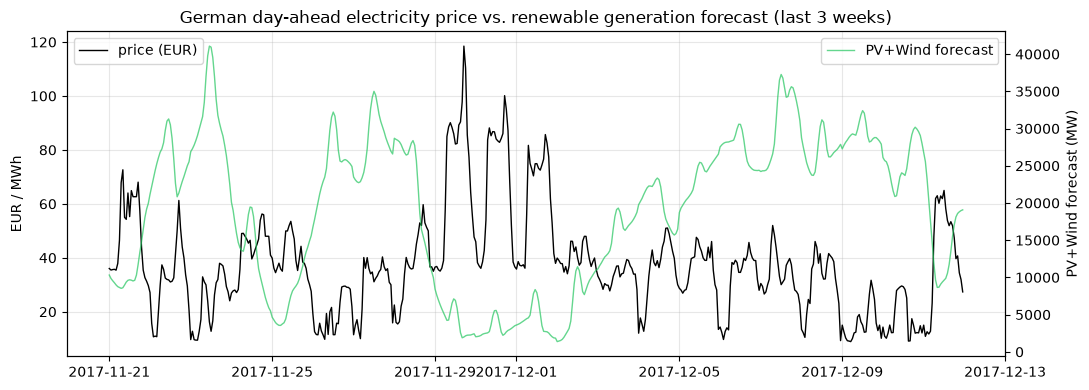

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 4))
recent = energy_df.tail(24 * 21)  # last 3 weeks
ax.plot(recent["timestamp"], recent["target"], color="black", lw=1, label="price (EUR)")
ax2 = ax.twinx()
ax2.plot(recent["timestamp"], recent["PV+Wind Forecast"], color="#22c55e", lw=1, alpha=0.7,
          label="PV+Wind forecast")
ax.set_title("German day-ahead electricity price vs. renewable generation forecast (last 3 weeks)")
ax.set_ylabel("EUR / MWh")
ax2.set_ylabel("PV+Wind forecast (MW)")
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### A proper rolling backtest, not a single lucky (or unlucky) day

Amazon's own quickstart notebook evaluates on a single 24-hour test day. That's fine for a
demo, but it's a sample size of one — not enough to draw a real conclusion from. Since the
covariate columns are already present for the *entire* series (they're forecasts, always
"known ahead" at every point in history), we can build our own, more rigorous backtest directly
from the training data: **14 independent rolling daily-origin windows** over the final two
weeks, each forecasting the next 24 hours from a different cutoff point, with **all** preceding
history as context. We report metrics averaged across all 14 windows.

The **final 14 days are never used as context or for fitting anything** — not the zero-shot
forecast, not the LoRA fine-tuning windows in Section 14. That's the leakage boundary that
matters most in this notebook.

In [4]:
HORIZON = 24            # hours (~1 day ahead), matches Amazon's own quickstart convention
N_BACKTEST_WINDOWS = 3 if (FAST_MODE or not USE_CUDA) else 14  # rolling daily origins over the final 2 weeks
COVARIATE_COLS = ["Ampirion Load Forecast", "PV+Wind Forecast"]

total_len = len(energy_df)
test_region_start = total_len - N_BACKTEST_WINDOWS * HORIZON
train_region = energy_df.iloc[:test_region_start].reset_index(drop=True)

backtest_windows = []
for w in range(N_BACKTEST_WINDOWS):
    cutoff = test_region_start + w * HORIZON
    context_slice = energy_df.iloc[:cutoff]
    future_slice = energy_df.iloc[cutoff: cutoff + HORIZON]
    backtest_windows.append({"context": context_slice, "future": future_slice})

print(f"Train region: {len(train_region):,} hours (up to {train_region['timestamp'].max()})")
print(f"{N_BACKTEST_WINDOWS} backtest windows of {HORIZON}h each, "
      f"first origin at {backtest_windows[0]['future']['timestamp'].iloc[0]}, "
      f"last window ends at {backtest_windows[-1]['future']['timestamp'].iloc[-1]}")

Train region: 51,600 hours (up to 2017-11-27 23:00:00)
14 backtest windows of 24h each, first origin at 2017-11-28 00:00:00, last window ends at 2017-12-11 23:00:00


<a id="zero-shot"></a>
## 10. Zero-shot forecasting

We load `amazon/chronos-2` and forecast every one of the 14 held-out days **without any
training on this dataset**. We print the live model config first — this is exactly where the
architecture numbers quoted in Section 2 come from, read from the checkpoint itself rather than
assumed.

In [5]:
import time
from chronos import BaseChronosPipeline, Chronos2Pipeline

if USE_CUDA:
    pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map="cuda")
else:
    pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-2")

cfg = pipeline.model.config.chronos_config
print(f"context_length: {cfg['context_length']}")
print(f"input_patch_size: {cfg['input_patch_size']}  output_patch_size: {cfg['output_patch_size']}")
print(f"max_output_patches: {cfg['max_output_patches']}  "
      f"-> max horizon = {cfg['max_output_patches'] * cfg['output_patch_size']}")
print(f"quantile levels shipped by this checkpoint ({len(cfg['quantiles'])} total): {cfg['quantiles']}")

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

context_length: 8192
input_patch_size: 16  output_patch_size: 16
max_output_patches: 64  -> max horizon = 1024
quantile levels shipped by this checkpoint (21 total): [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99]


In [6]:
QUANTILE_LEVELS = [0.1, 0.5, 0.9]

t0 = time.time()
zero_shot_preds = []
for win in backtest_windows:
    pred_df = pipeline.predict_df(
        win["context"][["id", "timestamp", "target"]],
        prediction_length=HORIZON,
        quantile_levels=QUANTILE_LEVELS,
        id_column="id",
        timestamp_column="timestamp",
        target="target",
    )
    zero_shot_preds.append(pred_df)
elapsed = time.time() - t0
if torch.cuda.is_available():
    torch.cuda.empty_cache()  # release cached (but unused) activations -- shared GPU, stay tidy
print(f"Zero-shot inference over {N_BACKTEST_WINDOWS} windows took {elapsed:.1f}s")
zero_shot_preds[0].head()

Zero-shot inference over 14 windows took 0.8s


,id,timestamp,target_name,predictions,0.1,0.5,0.9
0,DE,2017-11-28 00:00:00,target,11.699272,4.790035,11.699272,16.894995
1,DE,2017-11-28 01:00:00,target,9.967484,1.940769,9.967484,18.180756
2,DE,2017-11-28 02:00:00,target,9.384811,-1.058765,9.384811,18.766350
3,DE,2017-11-28 03:00:00,target,9.401089,-1.430546,9.401089,19.857433
4,DE,2017-11-28 04:00:00,target,10.849865,-2.262321,10.849865,22.552246


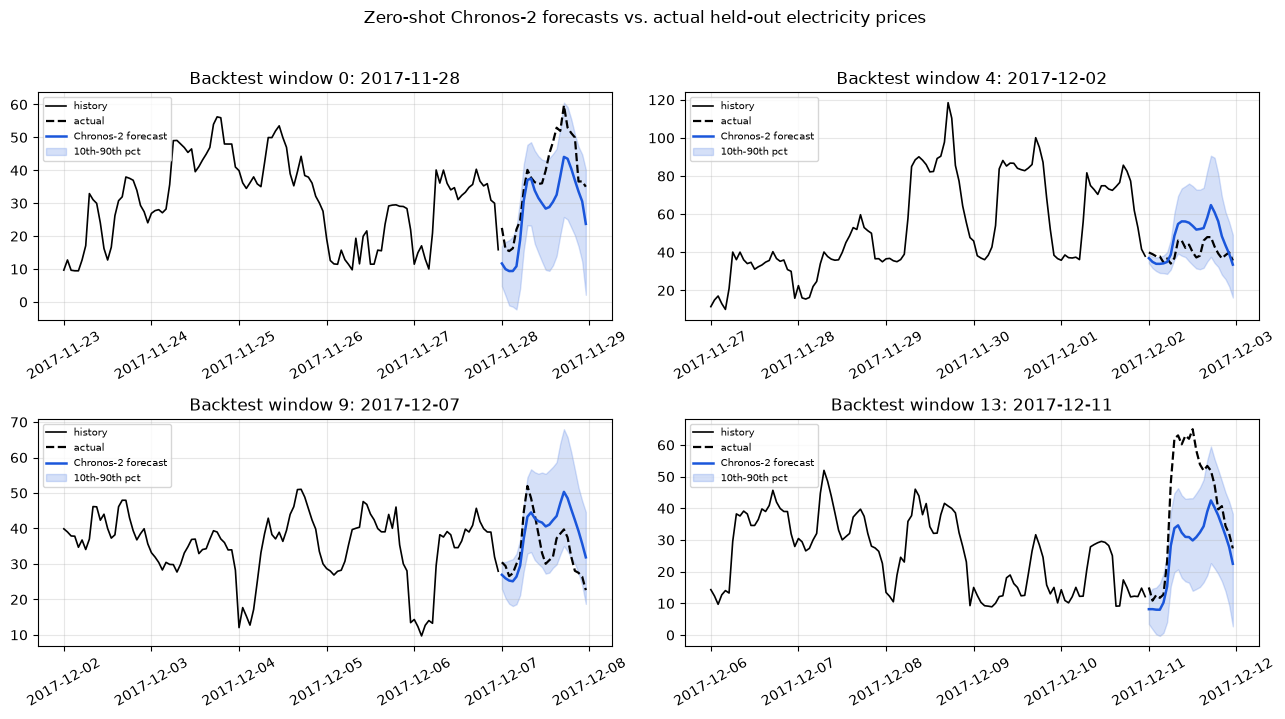

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
plot_windows = list(range(min(4, N_BACKTEST_WINDOWS)))
for ax, w in zip(axes.ravel(), plot_windows):
    ctx = backtest_windows[w]["context"].tail(24 * 5)
    fut = backtest_windows[w]["future"]
    pred = zero_shot_preds[w]
    ax.plot(ctx["timestamp"], ctx["target"], color="black", lw=1.2, label="history")
    ax.plot(fut["timestamp"], fut["target"], color="black", lw=1.6, ls="--", label="actual")
    ax.plot(pred["timestamp"], pred["predictions"], color="#1a56db", lw=1.8, label="Chronos-2 forecast")
    ax.fill_between(pred["timestamp"], pred["0.1"], pred["0.9"], color="#1a56db", alpha=0.18,
                     label="10th-90th pct")
    ax.set_title(f"Backtest window {w}: {fut['timestamp'].iloc[0].date()}")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=30)
fig.suptitle("Zero-shot Chronos-2 forecasts vs. actual held-out electricity prices", y=1.02)
plt.tight_layout()
plt.show()

## Metrics & baselines

We report **MAE** (original EUR units) and **sMAPE** (scale-free), averaged across all 14
backtest windows, alongside two classical baselines run on the exact same windows:

- **Naive** — repeat the last observed hour's price for all 24 future hours.
- **Seasonal-naive (t-24)** — repeat the price from exactly 24 hours earlier ("same hour
  yesterday"), the standard baseline for hourly data with daily seasonality.

In [8]:
def mae(actual, pred):
    return np.mean(np.abs(np.asarray(actual) - np.asarray(pred)))

def smape(actual, pred, eps=1e-8):
    actual, pred = np.asarray(actual), np.asarray(pred)
    return np.mean(200.0 * np.abs(actual - pred) / (np.abs(actual) + np.abs(pred) + eps))

def evaluate_windows(pred_dfs, label):
    maes, smapes = [], []
    for win, pred_df in zip(backtest_windows, pred_dfs):
        actual = win["future"]["target"].to_numpy()
        pred = pred_df["predictions"].to_numpy()
        maes.append(mae(actual, pred))
        smapes.append(smape(actual, pred))
    return {"method": label, "MAE": np.mean(maes), "sMAPE": np.mean(smapes)}

naive_preds = [pd.DataFrame({"predictions": np.full(HORIZON, win["context"]["target"].iloc[-1])})
               for win in backtest_windows]
seasonal_naive_preds = [pd.DataFrame({"predictions": win["context"]["target"].tail(24).to_numpy()})
                         for win in backtest_windows]

results = [
    evaluate_windows(naive_preds, "Naive (last value)"),
    evaluate_windows(seasonal_naive_preds, "Seasonal-naive (t-24)"),
    evaluate_windows(zero_shot_preds, "Chronos-2 zero-shot"),
]
pd.DataFrame(results).set_index("method").round(3)

,MAE,sMAPE
method,,
Naive (last value),15.477,44.509998
Seasonal-naive (t-24),12.261,34.944000
Chronos-2 zero-shot,8.235,27.865999


<a id="covariates"></a>
## 11. Covariates: native, no bolt-on regression

Now we pass `future_df` — the grid operator's own load and renewable-generation forecasts for
the horizon we're predicting. Chronos-2 handles this **in the same forward pass** via group
attention (Section 2.3); there's no separate regression step to configure.

In [9]:
t0 = time.time()
covariate_preds = []
for win in backtest_windows:
    future_covariates = win["future"][["id", "timestamp"] + COVARIATE_COLS]
    pred_df = pipeline.predict_df(
        win["context"][["id", "timestamp", "target"] + COVARIATE_COLS],
        future_df=future_covariates,
        prediction_length=HORIZON,
        quantile_levels=QUANTILE_LEVELS,
        id_column="id",
        timestamp_column="timestamp",
        target="target",
    )
    covariate_preds.append(pred_df)
elapsed = time.time() - t0
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print(f"Covariate-informed inference over {N_BACKTEST_WINDOWS} windows took {elapsed:.1f}s")

cov_result = evaluate_windows(covariate_preds, "Chronos-2 + covariates")
print(f"\nChronos-2 zero-shot only : MAE {results[2]['MAE']:.3f}  sMAPE {results[2]['sMAPE']:.3f}")
print(f"Chronos-2 + covariates   : MAE {cov_result['MAE']:.3f}  sMAPE {cov_result['sMAPE']:.3f}")

Covariate-informed inference over 14 windows took 1.2s

Chronos-2 zero-shot only : MAE 8.235  sMAPE 27.866
Chronos-2 + covariates   : MAE 4.745  sMAPE 14.533


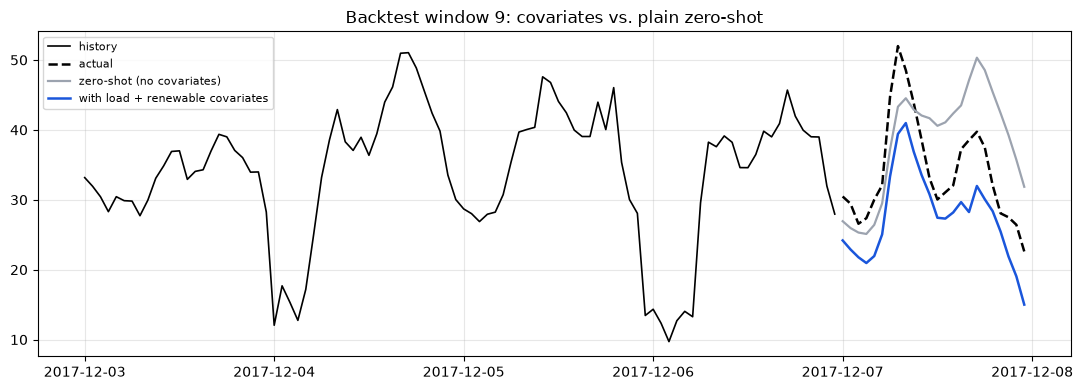

In [10]:
fig, ax = plt.subplots(figsize=(11, 4))
w = 9 if N_BACKTEST_WINDOWS >= 10 else max(0, N_BACKTEST_WINDOWS - 1)
ctx = backtest_windows[w]["context"].tail(24 * 4)
fut = backtest_windows[w]["future"]
ax.plot(ctx["timestamp"], ctx["target"], color="black", lw=1.2, label="history")
ax.plot(fut["timestamp"], fut["target"], color="black", lw=1.8, ls="--", label="actual")
ax.plot(fut["timestamp"], zero_shot_preds[w]["predictions"], color="#9ca3af", lw=1.6,
        label="zero-shot (no covariates)")
ax.plot(fut["timestamp"], covariate_preds[w]["predictions"], color="#1a56db", lw=1.8,
        label="with load + renewable covariates")
ax.set_title(f"Backtest window {w}: covariates vs. plain zero-shot")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<a id="cross-learning"></a>
## 12. Cross-learning across related series

`cross_learning=True` shares information across every series in a single `predict_df` batch —
useful when individual series have limited history. We demonstrate it on the **M4 hourly
dataset** (414 real hourly series from the M4 forecasting competition) rather than our
single-series electricity data, since cross-learning needs a genuine batch of related series to
have anything to share information *across*. Amazon's own paper uses a batch size of ~100 —
group attention makes memory use grow with batch size, so we size ours to what this notebook's
GPU actually has free (checked live below) rather than blindly copying their number.

In [11]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()

m4_df = pd.read_csv("https://autogluon.s3.amazonaws.com/datasets/timeseries/m4_hourly/train.csv")
print(f"M4 hourly: {m4_df['item_id'].nunique()} series, "
      f"{m4_df.groupby('item_id').size().min()}-{m4_df.groupby('item_id').size().max()} points each")

M4_HORIZON = 24
CROSS_LEARNING_BATCH = 10 if (FAST_MODE or not USE_CUDA) else 100
if torch.cuda.is_available():
    free_gb = torch.cuda.mem_get_info(0)[0] / 1e9
    if free_gb < 2.0:
        CROSS_LEARNING_BATCH = min(CROSS_LEARNING_BATCH, 30)
        print(f"Only {free_gb:.1f} GB free on this shared GPU -> using a batch of "
              f"{CROSS_LEARNING_BATCH} series (capped) to stay within budget.")

m4_subset = m4_df[m4_df["item_id"].isin(m4_df["item_id"].unique()[:CROSS_LEARNING_BATCH])]

t0 = time.time()
pred_independent = pipeline.predict_df(
    m4_subset, prediction_length=M4_HORIZON, quantile_levels=[0.5], batch_size=CROSS_LEARNING_BATCH,
    cross_learning=False,
)
t_independent = time.time() - t0
if torch.cuda.is_available():
    torch.cuda.empty_cache()

t0 = time.time()
pred_cross = pipeline.predict_df(
    m4_subset, prediction_length=M4_HORIZON, quantile_levels=[0.5], batch_size=CROSS_LEARNING_BATCH,
    cross_learning=True,
)
t_cross = time.time() - t0
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"Independent (cross_learning=False): {t_independent:.1f}s")
print(f"Cross-learning (cross_learning=True): {t_cross:.1f}s")

M4 hourly: 414 series, 700-960 points each


Independent (cross_learning=False): 0.3s
Cross-learning (cross_learning=True): 0.2s


We don't have ground truth beyond the training data for M4 hourly here, so we can't score
accuracy directly — this section is about the *mechanism and its cost*, not a win claim. Per
Amazon's own documented caveat (Section 7), cross-learning is task-dependent and not
guaranteed to improve accuracy; verify on your own held-out data before relying on it.

<a id="multivariate"></a>
## 13. Native multivariate forecasting (API mechanics)

Chronos-2's multivariate path takes either a 3D array `(batch, num_variates, history_length)`
or a list of dicts with a 2D `target` array. We don't have a genuinely multivariate real
dataset in this notebook (our electricity series is univariate-with-covariates, which is a
different input shape), so — exactly like Amazon's own quickstart notebook does for this same
section — we demonstrate the **API mechanics** on illustrative random data rather than pretend
a synthetic result is a real forecasting win.

In [12]:
from chronos.chronos2 import preprocess  # noqa: F401  (used again in Section 14)

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# 3D-array form: 32 series, 3 correlated variates each, 512 timesteps of history
multivariate_inputs = np.random.default_rng(SEED).standard_normal((32, 3, 512)).astype(np.float32)
mv_quantiles, mv_mean = pipeline.predict_quantiles(
    multivariate_inputs, prediction_length=48, quantile_levels=QUANTILE_LEVELS,
)
print(f"Multivariate output: {len(mv_quantiles)} series, "
      f"per-series quantile shape {mv_quantiles[0].shape}, mean shape {mv_mean[0].shape}")

# List-of-dicts form: explicit past/future covariates alongside a 2-variate target
rng = np.random.default_rng(SEED)
dict_inputs = [
    {
        "target": rng.standard_normal((2, 400)).astype(np.float32),
        "past_covariates": {"temperature": rng.standard_normal(400).astype(np.float32)},
        "future_covariates": {"temperature": rng.standard_normal(48).astype(np.float32)},
    }
    for _ in range(8)
]
dict_quantiles, dict_mean = pipeline.predict_quantiles(
    dict_inputs, prediction_length=48, quantile_levels=QUANTILE_LEVELS,
)
print(f"Multivariate + covariates output: {len(dict_quantiles)} series, "
      f"per-series quantile shape {dict_quantiles[0].shape}")

Multivariate output: 32 series, per-series quantile shape torch.Size([3, 48, 3]), mean shape torch.Size([3, 48])
Multivariate + covariates output: 8 series, per-series quantile shape torch.Size([2, 48, 3])


<a id="finetuning"></a>
## 14. Fine-tuning with LoRA

Chronos-2 ships a native `pipeline.fit()` method supporting either full fine-tuning or LoRA
adapters — confirmed directly from Amazon's own current quickstart notebook, not a stale or
unverified API. We fine-tune on the electricity price data, using the **same leakage boundary**
as the rest of this notebook: only the `train_region` (everything before the 14-day backtest
window) is used for fine-tuning.

Per Amazon's own warning (Section 7), fine-tuning is not guaranteed to beat zero-shot —
especially with limited data. We report whatever actually happens on our backtest, honestly.

**A note on API discrepancy we caught while verifying this section:** the `fit` docstring in
Amazon's own quickstart notebook recommends `learning_rate=1e-5` for LoRA, but the notebook's
own executed LoRA example cell actually uses `learning_rate=1e-4` and passes no explicit
`lora_config` at all (just `finetune_mode="lora"` with the library's internal defaults). We
follow the actually-executed value (`1e-4`, no custom `lora_config`) rather than the
docstring's text, since that's what Amazon's own team ran and verified works.

In [13]:
if not FINETUNE:
    print('Skipping fine-tuning (set CHRONOS2_TUTORIAL_FINETUNE=1 and run on CUDA to enable).')
else:
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    train_inputs = preprocess.from_data_frame(
        train_region[["id", "timestamp", "target"] + COVARIATE_COLS],
        target_columns=["target"],
        prediction_length=HORIZON,
        id_column="id",
        timestamp_column="timestamp",
        known_covariates_names=COVARIATE_COLS,
    )
    
    FT_BATCH_SIZE = 16  # reduced from Amazon's own batch_size=32 default -- fine-tuning needs
                         # gradients + optimizer state on top of activations, and this is a shared
                         # 8GB GPU that other local processes also draw from
    
    t0 = time.time()
    finetuned_pipeline = pipeline.fit(
        inputs=train_inputs,
        prediction_length=HORIZON,
        finetune_mode="lora",
        learning_rate=1e-4,
        num_steps=(50 if FAST_MODE else 500),
        batch_size=FT_BATCH_SIZE,
        logging_steps=100,
    )
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print(f"LoRA fine-tuning took {time.time() - t0:.1f}s")

Step,Training Loss
100,0.645107
200,0.614400
300,0.585600
400,0.578258
500,0.596381


LoRA fine-tuning took 418.2s


In [14]:
if not FINETUNE:
    print('Fine-tuning skipped -> no fine-tuned evaluation.')
else:
    t0 = time.time()
    finetuned_preds = []
    for win in backtest_windows:
        future_covariates = win["future"][["id", "timestamp"] + COVARIATE_COLS]
        pred_df = finetuned_pipeline.predict_df(
            win["context"][["id", "timestamp", "target"] + COVARIATE_COLS],
            future_df=future_covariates,
            prediction_length=HORIZON,
            quantile_levels=QUANTILE_LEVELS,
            id_column="id",
            timestamp_column="timestamp",
            target="target",
        )
        finetuned_preds.append(pred_df)
    elapsed = time.time() - t0
    print(f"Fine-tuned inference over {N_BACKTEST_WINDOWS} windows took {elapsed:.1f}s")
    
    ft_result = evaluate_windows(finetuned_preds, "Chronos-2 + LoRA fine-tuning")
    print(f"\nChronos-2 + covariates (zero-shot) : MAE {cov_result['MAE']:.3f}  sMAPE {cov_result['sMAPE']:.3f}")
    print(f"Chronos-2 + covariates + LoRA fine-tune : MAE {ft_result['MAE']:.3f}  sMAPE {ft_result['sMAPE']:.3f}")

Fine-tuned inference over 14 windows took 1.4s

Chronos-2 + covariates (zero-shot) : MAE 4.745  sMAPE 14.533
Chronos-2 + covariates + LoRA fine-tune : MAE 5.125  sMAPE 15.721


<a id="final"></a>
## 15. Final comparison

Every row below is evaluated on the identical 14-window, 24-hour-ahead backtest.

In [15]:
final_results = results + [cov_result]
if FINETUNE:
    final_results.append(ft_result)
final_table = pd.DataFrame(final_results).set_index("method").round(3)
final_table

,MAE,sMAPE
method,,
Naive (last value),15.477,44.509998
Seasonal-naive (t-24),12.261,34.944000
Chronos-2 zero-shot,8.235,27.865999
Chronos-2 + covariates,4.745,14.533000
Chronos-2 + LoRA fine-tuning,5.125,15.721000


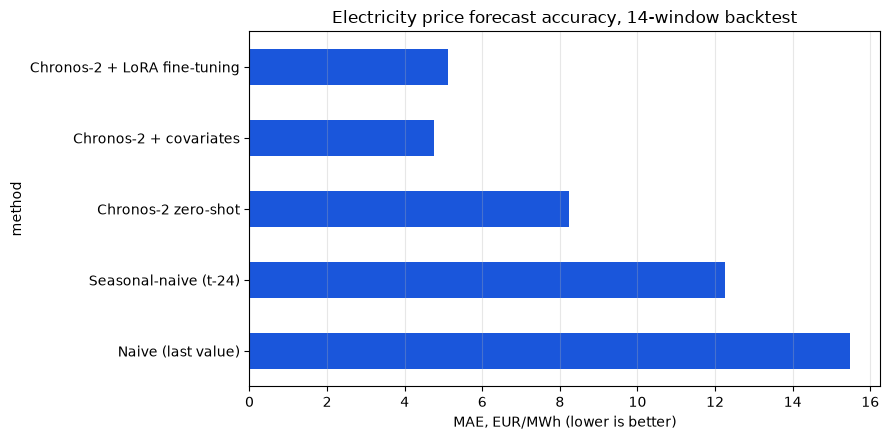

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.5))
final_table["MAE"].plot(kind="barh", ax=ax, color="#1a56db")
ax.set_xlabel("MAE, EUR/MWh (lower is better)")
ax.set_title("Electricity price forecast accuracy, 14-window backtest")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

**Read these numbers honestly.** Whichever method wins in your run is the real result. A few
things worth keeping in mind before drawing conclusions:

- Electricity prices have strong daily seasonality, so seasonal-naive is a genuinely strong,
  "unfair" baseline here — exactly like the seasonal-naive baseline in the companion TimesFM
  notebook. If Chronos-2 doesn't clearly beat it, that's a real finding about this dataset, not
  a tutorial failure.
- Our LoRA fine-tuning run uses modest settings (500 steps, batch size 64) to keep runtime
  reasonable — a production adapter trained longer, with hyperparameter tuning (as Amazon's own
  docs recommend), may look different.
- The covariates here are themselves *forecasts* (load and renewable generation forecasts), so
  their own forecast error becomes part of Chronos-2's effective input noise — a realistic
  constraint any real trading desk would also face.

<a id="references"></a>
## 16. References

- Ansari, A. F. et al. *Chronos-2: From Univariate to Universal Forecasting*, arXiv Oct 2025.
  [arXiv:2510.15821](https://arxiv.org/abs/2510.15821)
- Ansari, A. F. et al. *Chronos: Learning the Language of Time Series*, TMLR 2024.
  [arXiv:2403.07815](https://arxiv.org/abs/2403.07815) / [OpenReview](https://openreview.net/forum?id=gerNCVqqtR)
- Official repository: [github.com/amazon-science/chronos-forecasting](https://github.com/amazon-science/chronos-forecasting)
- Official quickstart notebook: [notebooks/chronos-2-quickstart.ipynb](https://github.com/amazon-science/chronos-forecasting/blob/main/notebooks/chronos-2-quickstart.ipynb)
- Hugging Face model: [amazon/chronos-2](https://huggingface.co/amazon/chronos-2)
- Amazon Science blog: [Introducing Chronos-2: From Univariate to Universal Forecasting](https://www.amazon.science/blog/introducing-chronos-2-from-univariate-to-universal-forecasting)
- Chronos-Bolt blog post: [Fast and accurate zero-shot forecasting with Chronos-Bolt and AutoGluon](https://aws.amazon.com/blogs/machine-learning/fast-and-accurate-zero-shot-forecasting-with-chronos-bolt-and-autogluon/)
- GIFT-Eval leaderboard (check live for current cross-model rankings): [huggingface.co/spaces/Salesforce/GIFT-Eval](https://huggingface.co/spaces/Salesforce/GIFT-Eval)
- Dataset: German day-ahead electricity price + M4 hourly, both mirrored on AutoGluon's public
  S3 bucket, as used in Amazon's own official Chronos-2 quickstart notebook.

## What you now know

You can now: explain Chronos-2's encoder-only, T5-derived, group-attention architecture and how
it differs from Chronos v1 and Chronos-Bolt; load a pretrained checkpoint and get zero-shot
point + quantile forecasts; add native future covariates with no bolt-on regression step; use
cross-learning across a batch of related series; recognize the multivariate input format; and
fine-tune Chronos-2 with LoRA on your own data — all while knowing exactly which claims about
the model are independently verified versus self-reported.

**Natural next steps:** try Chronos-2 on a genuinely multivariate real dataset (multiple
correlated sensor channels, or several interconnected national grids' prices) instead of the
illustrative example in Section 13; benchmark against the companion TimesFM tutorial's results
on the same electricity dataset; or push a LoRA adapter further with proper hyperparameter
search instead of this notebook's deliberately modest settings.